In [1]:
import os

DATASET_PATH = "/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm"
print("Dataset Exists :", os.path.exists(DATASET_PATH))
for item in os.listdir(DATASET_PATH):
    print(item)

Dataset Exists : True
for-norm


## Checking the structure of data

In [14]:
import os

DATASET_PATH = "/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm"

print("Dataset Exists :", os.path.exists(DATASET_PATH))
print()

# list top level
for item in os.listdir(DATASET_PATH):
    item_path = os.path.join(DATASET_PATH, item)
    print(f"{item}/")
    
    # list inside each subfolder
    if os.path.isdir(item_path):
        for sub in os.listdir(item_path):
            sub_path = os.path.join(item_path, sub)
            print(f"  {sub}/")
            
            # list inside each sub-subfolder
            if os.path.isdir(sub_path):
                for subsub in os.listdir(sub_path)[:3]:  # show first 3 files only
                    print(f"    {subsub}")
                print(f"    ... total: {len(os.listdir(sub_path))} files")

Dataset Exists : True

for-norm/
  validation/
    fake
    real
    ... total: 2 files
  training/
    fake
    real
    ... total: 2 files
  testing/
    fake
    real
    ... total: 2 files


## Defining paths

In [2]:
DATASET_PATH = "/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm"

train_real = os.path.join(DATASET_PATH, "training", "real")
train_fake = os.path.join(DATASET_PATH, "training", "fake")

val_real = os.path.join(DATASET_PATH, "validation", "real")
val_fake = os.path.join(DATASET_PATH, "validation", "fake")

test_real = os.path.join(DATASET_PATH, "testing", "real")
test_fake = os.path.join(DATASET_PATH, "testing", "fake")

print("Training Real :", len(os.listdir(train_real)))
print("Training Fake :", len(os.listdir(train_fake)))
print()
print("Validation Real :", len(os.listdir(val_real)))
print("Validation Fake :", len(os.listdir(val_fake)))
print()
print("Testing Real :", len(os.listdir(test_real)))
print("Testing Fake :", len(os.listdir(test_fake)))

Training Real : 26941
Training Fake : 26927

Validation Real : 5400
Validation Fake : 5398

Testing Real : 2264
Testing Fake : 2370


In [5]:

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

## Waveform Visualization

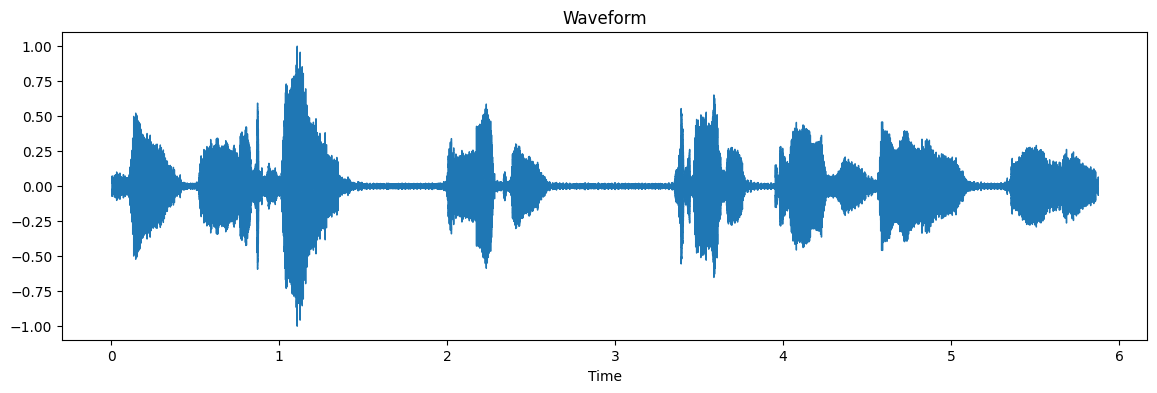

In [19]:
plt.figure(figsize=(14,4))
librosa.display.waveshow(audio,sr=sr)

plt.title("Waveform")
plt.show()

## Spectral Centroid over waveform

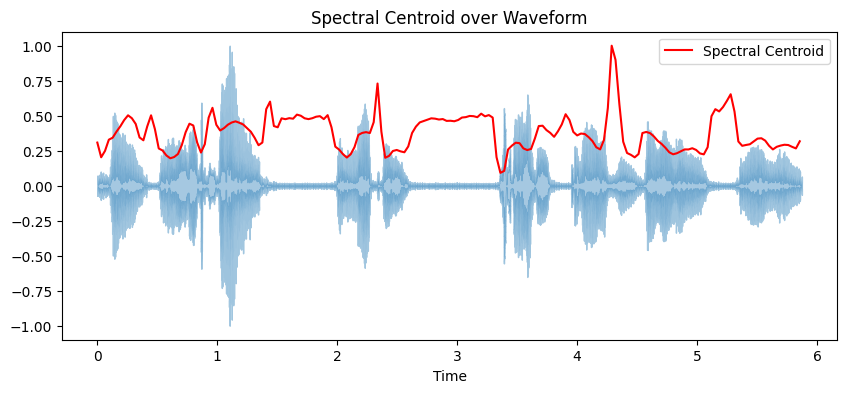

In [21]:
spec_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)[0]
frames = range(len(spec_centroid))
t = librosa.frames_to_time(frames, sr=sr)

plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sr, alpha=0.4)
plt.plot(t, spec_centroid / spec_centroid.max(), color='r', label='Spectral Centroid')
plt.title("Spectral Centroid over Waveform")
plt.legend()
plt.show()

## MFCC Heatmap

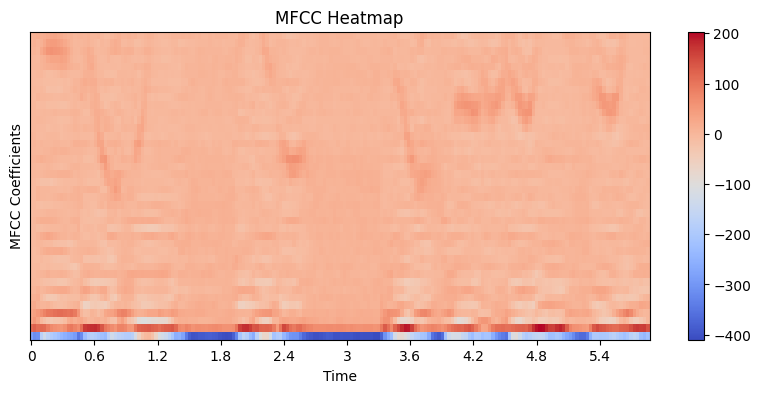

In [20]:
mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc, sr=sr, x_axis='time')
plt.colorbar()
plt.title("MFCC Heatmap")
plt.ylabel("MFCC Coefficients")
plt.show()

## function to extract features

In [8]:
def extract_features(file_path):

    audio, sr = librosa.load(
        file_path,
        sr=16000
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    mfcc_mean = np.mean(
        mfcc.T,
        axis=0
    )

    return mfcc_mean

## Processing training data

In [9]:
X = []
y = []

## extracting feature for train_real

In [10]:
from tqdm import tqdm

for file in tqdm(os.listdir(train_real)):
    path = os.path.join(train_real, file)
    try:
        feature = extract_features(path)
        X.append(feature)
        y.append(0)
    except:
        pass

 13%|█▎        | 3476/26941 [01:39<07:57, 49.15it/s] /usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1837
  warnings.warn(
 61%|██████    | 16441/26941 [06:18<03:16, 53.55it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=0
  warnings.warn(
100%|██████████| 26941/26941 [10:30<00:00, 42.72it/s]


## Extracting features for train_fake

In [11]:
for file in tqdm(os.listdir(train_fake)):
    path = os.path.join(train_fake, file)
    try:
        feature = extract_features(path)
        X.append(feature)
        y.append(1)
    except:
        pass

 91%|█████████ | 24556/26927 [07:28<00:40, 58.15it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1891
  warnings.warn(
100%|██████████| 26927/26927 [08:09<00:00, 54.97it/s]


In [12]:
X = np.array(X)
y = np.array(y)

print("Feature Shape :", X.shape)
print("Label Shape :", y.shape)

Feature Shape : (53868, 40)
Label Shape : (53868,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42,stratify=y)

print("Train Shape :", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape : (43094, 40)
Test Shape : (10774, 40)


## Model training

In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=-1)
print("Model Created")

Model Created


In [15]:
model.fit(X_train,y_train)
print("Training Complete")

Training Complete


In [83]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test,predictions)
print("Accuracy :", accuracy)

Accuracy : 0.9806014479302023


In [84]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      5388
           1       0.98      0.98      0.98      5386

    accuracy                           0.98     10774
   macro avg       0.98      0.98      0.98     10774
weighted avg       0.98      0.98      0.98     10774



In [85]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,predictions)
print(cm)

[[5261  127]
 [  82 5304]]


## Evaluating performance on validation data

In [19]:
val_real_files = os.listdir(val_real)
val_fake_files = os.listdir(val_fake)

print("Validation Real :", len(val_real_files))
print("Validation Fake :", len(val_fake_files))

Validation Real : 5400
Validation Fake : 5398


In [21]:
X_val = []
y_val = []

## Extracting Validation features 

In [22]:
for file in tqdm(val_real_files):

    path = os.path.join(val_real,file)
    try:

        feature = extract_features(path)
        X_val.append(feature)
        y_val.append(0)

    except:
        pass

 24%|██▍       | 1321/5400 [00:33<01:39, 41.12it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1690
  warnings.warn(
100%|██████████| 5400/5400 [02:09<00:00, 41.63it/s]


In [23]:
for file in tqdm(val_fake_files):

    path = os.path.join(val_fake,file)
    try:

        feature = extract_features(path)
        X_val.append(feature)
        y_val.append(1)

    except:
        pass

100%|██████████| 5398/5398 [01:44<00:00, 51.76it/s]


In [24]:
X_val = np.array(X_val)
y_val = np.array(y_val)

print(X_val.shape)
print(y_val.shape)

(10798, 40)
(10798,)


In [55]:
import numpy as np

# Save both arrays into one file
np.savez_compressed('audio_features_data_val.npz', X=X_val, y=y_val)
print("Arrays saved successfully as a compressed .npz file!")

Arrays saved successfully as a compressed .npz file!


In [86]:
val_predictions = model.predict(X_val)

In [87]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

val_accuracy = accuracy_score(y_val, val_predictions)
print("Validation Accuracy :", val_accuracy)

Validation Accuracy : 0.9789775884423041


In [88]:
print(classification_report(y_val,val_predictions))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      5400
           1       0.98      0.98      0.98      5398

    accuracy                           0.98     10798
   macro avg       0.98      0.98      0.98     10798
weighted avg       0.98      0.98      0.98     10798



In [28]:
import joblib
joblib.dump( model,"model.pkl")
print("Model Saved Successfully")

Model Saved Successfully


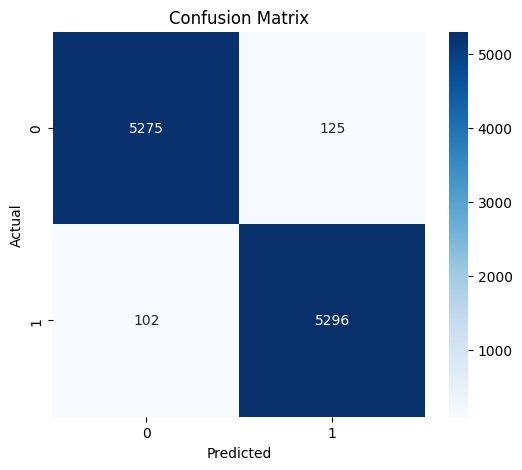

In [89]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, val_predictions)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png",bbox_inches="tight")
plt.show()

## Calculating EER On validation data

In [90]:
from sklearn.metrics import roc_curve
import numpy as np
probs = model.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, probs)
fnr = 1 - tpr
eer_threshold = thresholds[np.nanargmin(np.absolute((fnr - fpr)))]
eer = fpr[np.nanargmin(np.absolute((fnr - fpr)))]
print("Equal Error Rate (EER): {:.4f}".format(eer))

Equal Error Rate (EER): 0.0209


In [33]:
def predict_audio(file_path):

    audio, sr = librosa.load(file_path,sr=16000)
    mfcc = librosa.feature.mfcc(y=audio,sr=sr,n_mfcc=40)
    features = np.mean( mfcc.T, axis=0).reshape(1, -1)

    prediction = model.predict(features)[0]

    probability = model.predict_proba(features)[0]
    confidence = np.max(probability) * 100
    label = ("Genuine"if prediction == 0 else "Deepfake" ) 

    return label, 


In [34]:
sample_test = os.path.join(test_real,os.listdir(test_real)[0])
sample_test

'/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/testing/real/file508.wav_16k.wav_norm.wav_mono.wav_silence.wav'

In [35]:
label, confidence = predict_audio(sample_test)

print("Prediction :", label)
print("Confidence :", confidence)

Prediction : Genuine
Confidence : 69.0


## Evaluating performance on test data

In [37]:
X_test_final = []
y_test_final = []

for file in tqdm(os.listdir(test_real), desc="Test Real"):
    path = os.path.join(test_real, file)
    try:
        feature = extract_features(path)
        X_test_final.append(feature)
        y_test_final.append(0)
    except:
        pass

for file in tqdm(os.listdir(test_fake), desc="Test Fake"):
    path = os.path.join(test_fake, file)
    try:
        feature = extract_features(path)
        X_test_final.append(feature)
        y_test_final.append(1)
    except:
        pass

X_test_final = np.array(X_test_final)
y_test_final = np.array(y_test_final)

print("Test Feature Shape :", X_test_final.shape)
print("Test Label Shape   :", y_test_final.shape)

Test Fake: 100%|██████████| 2370/2370 [00:35<00:00, 67.55it/s]

Test Feature Shape : (4634, 40)
Test Label Shape   : (4634,)


In [91]:
test_predictions = model.predict(X_test_final)
test_accuracy = accuracy_score(y_test_final, test_predictions)
print("Test Accuracy :", test_accuracy)
print()
print(classification_report(y_test_final, test_predictions))

Test Accuracy : 0.8851963746223565

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      2264
           1       0.88      0.90      0.89      2370

    accuracy                           0.89      4634
   macro avg       0.89      0.88      0.89      4634
weighted avg       0.89      0.89      0.89      4634



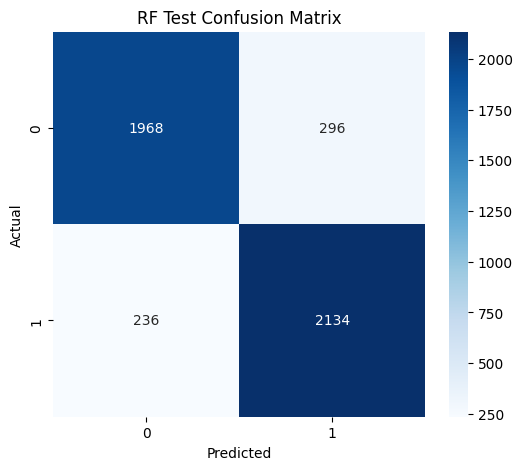

In [92]:
cm = confusion_matrix(y_test_final, test_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RF Test Confusion Matrix")
plt.savefig("confusion_matrix_test.png",bbox_inches="tight")
plt.show()

In [93]:
probs = model.predict_proba(X_test_final)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_final, probs)
fnr = 1 - tpr
eer_threshold = thresholds[np.nanargmin(np.absolute((fnr - fpr)))]
eer = fpr[np.nanargmin(np.absolute((fnr - fpr)))]
print("Equal Error Rate (EER): {:.4f}".format(eer))

Equal Error Rate (EER): 0.1153


## Per-class performance

In [43]:
X_real = X_test_final[y_test_final == 0]
X_fake = X_test_final[y_test_final == 1]
print("X_real shape:", X_real.shape)
print("X_fake shape:", X_fake.shape)

X_real shape: (2264, 40)
X_fake shape: (2370, 40)


In [47]:
y_real = y_test_final[y_test_final == 0]
y_fake = y_test_final[y_test_final == 1]

In [74]:
test_predictions_real = model.predict(X_real)
test_accuracy_real = accuracy_score(y_real, test_predictions_real)
print("Test Accuracy on real class :", test_accuracy_real)
print()
print(classification_report(y_real, test_predictions_real))

Test Accuracy on real class : 0.8692579505300353

              precision    recall  f1-score   support

           0       1.00      0.87      0.93      2264
           1       0.00      0.00      0.00         0

    accuracy                           0.87      2264
   macro avg       0.50      0.43      0.47      2264
weighted avg       1.00      0.87      0.93      2264



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [73]:
test_predictions_fake = model.predict(X_fake)
test_accuracy_fake = accuracy_score(y_fake, test_predictions_fake)
print("Test Accuracy on fake class :", test_accuracy_fake)
print()
print(classification_report(y_fake, test_predictions_fake))

Test Accuracy on fake class : 0.90042194092827

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.90      0.95      2370

    accuracy                           0.90      2370
   macro avg       0.50      0.45      0.47      2370
weighted avg       1.00      0.90      0.95      2370



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
